# Naive Bayes Classifier
> <span style='color:deepskyblue'>drug.csv</span>

In [47]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [48]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [49]:
# encoding 
encoders = {}

categorical_cols = ["Gender", "BloodPressure", "Cholestrol", "Class"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [50]:
df.sample(3)

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
211,35,0,0,0,12.894000,0
256,61,1,2,0,9.443000,3
381,49,1,0,1,8.650711,0


In [51]:
# features and target
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [52]:
# model train
nb = GaussianNB()
nb.fit(x_train, y_train)

GaussianNB()

In [53]:
y_pred = nb.predict(x_test)

In [57]:
# evaluation
print('accuracy_score:', accuracy_score(y_test, y_pred))
print('\n')
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoders["Class"].classes_
    )
)

accuracy_score: 0.9560439560439561



Classification Report:
              precision    recall  f1-score   support

       drugA       0.95      1.00      0.97        18
       drugB       0.95      1.00      0.97        18
       drugC       0.90      1.00      0.95        18
       drugX       1.00      1.00      1.00        19
       drugY       1.00      0.78      0.88        18

    accuracy                           0.96        91
   macro avg       0.96      0.96      0.95        91
weighted avg       0.96      0.96      0.95        91



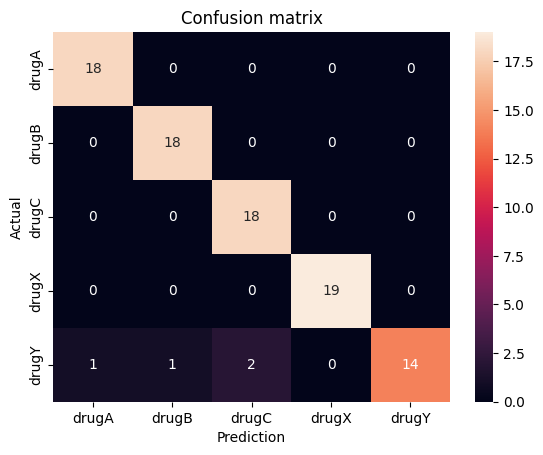

In [59]:
# confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, xticklabels=encoders['Class'].classes_, yticklabels=encoders["Class"].classes_)
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

In [64]:
# user input
age = int(input('AGE: '))
gender = input('GENDER [F/M]: ')
bp = input("Blood Pressure (HIGH/LOW/NORMAL): ")
chol = input("Cholestrol (HIGH/NORMAL): ")
na_to_k = float(input("Na_to_K: "))


# encoding the categorical values
gender = encoders['Gender'].transform([gender])[0]
bp = encoders['BloodPressure'].transform([bp])[0]
chol = encoders['Cholestrol'].transform([chol])[0]

user_ip = np.array([[age, gender, bp, chol, na_to_k]])
probabilities = nb.predict_proba(user_ip)[0]
print(probabilities)

prediction = nb.predict(user_ip)[0]
print(prediction)


predicted_drug = encoders['Class'].inverse_transform([prediction])[0] 
print('predicted drug: ',predicted_drug)

[0.00000000e+00 0.00000000e+00 9.99999597e-01 3.31865864e-07
 7.08896446e-08]
2
predicted drug:  drugC


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
